In [ ]:
# =============================================================================
# Renaissance HTR — Baseline TrOCR Fine-tuning
# Google Colab (T4) | 122 labelled lines | trocr-base-handwritten
# =============================================================================
# CELL ORDER (copy each block into a Colab cell):
#   0. Install & imports
#   1. Mount Drive + build manifest
#   2. Augmentation pipeline
#   3. Dataset class
#   4. Train / val split  (stratified by page)
#   5. Model setup + two-phase freeze config
#   6. Differential LR optimizer + scheduler
#   7. CER / WER compute_metrics
#   8. Phase 1 training  (encoder frozen)
#   9. Phase 2 training  (gradual encoder unfreeze)
#  10. Final evaluation  + error analysis
# =============================================================================

# ── CELL 0 · Install dependencies ─────────────────────────────────────────────
# Upgrading to latest to resolve the EncoderDecoderCache import error
!pip install -q -U transformers peft datasets evaluate jiwer albumentations opencv-python-headless scikit-learn matplotlib seaborn

In [ ]:
# ── CELL 1 · Imports + Drive mount + Manifest builder ─────────────────────────
import os, json, re, random
from pathlib import Path

import numpy as np
import torch
from PIL import Image
from sklearn.model_selection import train_test_split

from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    EarlyStoppingCallback,
)
import evaluate

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths (edit to match your Drive layout) ───────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

EXPORT_DIR  = "/content/drive/MyDrive/Spanish_16c/dataset_export"   # from extraction cell
WORK_DIR    = "/content/renaissance_htr"                             # local scratch
MANIFEST    = os.path.join(WORK_DIR, "manifest.json")
CHECKPOINT  = os.path.join(WORK_DIR, "checkpoints")

os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(CHECKPOINT, exist_ok=True)

# ── Build manifest from exported png/txt pairs ────────────────────────────────
def build_manifest(export_dir: str, manifest_path: str) -> list[dict]:
    """
    Scans export_dir for paired <stem>.png + <stem>.txt files.
    Returns list of {"image": "stem.png", "text": "...", "page": N}.
    """
    samples = []
    png_files = sorted(Path(export_dir).glob("*.png"))
    skipped = 0

    for png in png_files:
        txt_path = png.with_suffix(".txt")
        if not txt_path.exists():
            skipped += 1
            continue

        text = txt_path.read_text(encoding="utf-8").strip()
        if not text:                   # skip blank-label lines
            skipped += 1
            continue

        # page index is the first numeric token in the filename, e.g. "3_page..."
        page_match = re.match(r"(\d+)_", png.name)
        page = int(page_match.group(1)) if page_match else 0

        samples.append({
            "image": png.name,
            "text":  text,
            "page":  page,
        })

    with open(manifest_path, "w", encoding="utf-8") as f:
        json.dump(samples, f, ensure_ascii=False, indent=2)

    print(f"Manifest: {len(samples)} samples across "
          f"{len(set(s['page'] for s in samples))} pages  |  "
          f"skipped {skipped}")
    return samples

ALL_SAMPLES = build_manifest(EXPORT_DIR, MANIFEST)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Manifest: 121 samples across 5 pages  |  skipped 1


In [ ]:
# ── CELL 2 · Augmentation pipeline ────────────────────────────────────────────
import albumentations as A
import cv2

# Augmentations calibrated for 16-17c degraded handwriting.
# Applied only during training — validation always gets clean images.
TRAIN_TRANSFORM = A.Compose([
    # ── Handwriting stroke variation ──────────────────────────────────────
    A.ElasticTransform(
        alpha=20, sigma=4,               # subtle, not cartoonish
        p=0.4
    ),
    A.GridDistortion(
        num_steps=4, distort_limit=0.08, # parchment warp
        p=0.3
    ),

    # ── Historical document degradation ───────────────────────────────────
    A.RandomBrightnessContrast(
        brightness_limit=0.25,           # ink fading / darkening
        contrast_limit=0.25,
        p=0.5
    ),
    A.GaussNoise(
        std_range=(0.03, 0.15),           # paper grain
        p=0.4
    ),
    A.MotionBlur(blur_limit=3, p=0.2),   # ink bleed / scan motion

    # ── Geometry ──────────────────────────────────────────────────────────
    A.Affine(
        translate_percent=0.03,
        scale=(0.92, 1.08),
        rotate=(-2, 2),
        border_mode=cv2.BORDER_REPLICATE,
        p=0.5
    ),
    A.Perspective(
        scale=(0.01, 0.04),             # subtle 3-D tilt
        p=0.25
    ),

    # ── Occlusion simulation ──────────────────────────────────────────────
    A.CoarseDropout(num_holes_range=(1, 4),
                    hole_height_range=(4, 8),
                    hole_width_range=(8, 20),
                    fill=255,   # white dropout (torn paper)
                    p=0.2),
])

def apply_augmentation(pil_img: Image.Image) -> Image.Image:
    img_np = np.array(pil_img)
    augmented = TRAIN_TRANSFORM(image=img_np)["image"]
    return Image.fromarray(augmented)

In [ ]:
# ── CELL 3 · Dataset class ─────────────────────────────────────────────────────
from torch.utils.data import Dataset

class RenaissanceHTRDataset(Dataset):
    """
    Wraps manifest samples for TrOCR fine-tuning.

    Args:
        samples         list of {"image", "text", "page"}
        image_dir       directory containing the .png files
        processor       TrOCRProcessor
        augment         bool — enable albumentations pipeline
        max_target_len  token budget for labels
    """
    def __init__(
        self,
        samples: list[dict],
        image_dir: str,
        processor: TrOCRProcessor,
        augment: bool = False,
        max_target_len: int = 128,
    ):
        self.samples       = samples
        self.image_dir     = image_dir
        self.processor     = processor
        self.augment       = augment
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # ── Load image ────────────────────────────────────────────────────
        img_path = os.path.join(self.image_dir, sample["image"])
        img = Image.open(img_path).convert("RGB")

        if self.augment:
            img = apply_augmentation(img)

        pixel_values = self.processor(
            img, return_tensors="pt"
        ).pixel_values.squeeze(0)          # (C, H, W)

        # ── Tokenize label ────────────────────────────────────────────────
        labels = self.processor.tokenizer(
            sample["text"],
            padding="max_length",
            max_length=self.max_target_len,
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)           # (max_target_len,)

        # Mask padding — pad_token_id is 1 for RoBERTa
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {"pixel_values": pixel_values, "labels": labels}


In [ ]:
# ── CELL 4 · Stratified train / val split ─────────────────────────────────────
def stratified_split(
    samples: list[dict],
    val_ratio: float = 0.20,
    seed: int = SEED,
) -> tuple[list[dict], list[dict]]:
    """
    Stratify by page number so every page contributes to both splits.
    Falls back to random split if any stratum is too small.
    """
    pages = np.array([s["page"] for s in samples])
    unique_pages = np.unique(pages)

    train_list, val_list = [], []

    for page in unique_pages:
        page_samples = [s for s in samples if s["page"] == page]

        if len(page_samples) < 2:          # singleton — force into train
            train_list.extend(page_samples)
            continue

        n_val = max(1, round(len(page_samples) * val_ratio))
        random.seed(int(seed + page))
        random.shuffle(page_samples)
        val_list.extend(page_samples[:n_val])
        train_list.extend(page_samples[n_val:])

    print(f"Split → train: {len(train_list)}  |  val: {len(val_list)}")
    pages_in_val = set(s["page"] for s in val_list)
    print(f"Pages represented in val: {sorted(pages_in_val)}")
    return train_list, val_list

TRAIN_SAMPLES, VAL_SAMPLES = stratified_split(ALL_SAMPLES, val_ratio=0.20)

Split → train: 97  |  val: 24
Pages represented in val: [1, 2, 3, 4, 5]


In [ ]:
# ── CELL 5 · Model setup + phase-based freeze config ──────────────────────
MODEL_NAME = "microsoft/trocr-base-handwritten"

processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
model     = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)

# ── Sanity check: trocr-base uses a RoBERTa decoder, NOT BERT
# RoBERTa: bos=0 (<s>), pad=1, eos=2 (</s>)
# cls_token_id and sep_token_id are None → crash if used
print("Token IDs:")
print(f"  bos_token_id : {processor.tokenizer.bos_token_id}")  # 0
print(f"  eos_token_id : {processor.tokenizer.eos_token_id}")  # 2
print(f"  pad_token_id : {processor.tokenizer.pad_token_id}")  # 1
print(f"  cls_token_id : {processor.tokenizer.cls_token_id}")  # None ← never use this

assert processor.tokenizer.bos_token_id is not None, "bos_token_id is None!"
assert processor.tokenizer.eos_token_id is not None, "eos_token_id is None!"
assert processor.tokenizer.pad_token_id is not None, "pad_token_id is None!"

# ── Decoder token config ──────────────────────────────────────────────────
model.config.decoder_start_token_id = processor.tokenizer.bos_token_id  # 0
model.config.eos_token_id           = processor.tokenizer.eos_token_id  # 2
model.config.pad_token_id           = processor.tokenizer.pad_token_id  # 1
model.config.vocab_size             = model.config.decoder.vocab_size

# ── CRITICAL: disable cache for training (transformers 4.40+ requirement)
# Without this, the decoder enters the cached generation path during
# training steps and raises "decoder_input_ids or decoder_inputs_embeds"
model.config.use_cache = False

# ── Beam search config (only active during model.generate(), not training)
model.generation_config.max_new_tokens       = 128
model.generation_config.no_repeat_ngram_size = 3
model.generation_config.length_penalty       = 1.0
model.generation_config.num_beams            = 4
model.generation_config.early_stopping       = True

# ── Dropout
model.encoder.config.hidden_dropout_prob          = 0.1
model.encoder.config.attention_probs_dropout_prob = 0.1
model.decoder.config.dropout                      = 0.1


def freeze_encoder(m):
    for p in m.encoder.parameters():
        p.requires_grad = False
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"[Phase 1] Encoder frozen — trainable params: {n:,}")


def unfreeze_encoder_top_k(m, k=2):
    for block in m.encoder.encoder.layer[-k:]:
        for p in block.parameters():
            p.requires_grad = True
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"[Phase 2] Top-{k} encoder blocks unfrozen — trainable params: {n:,}")


freeze_encoder(model)

# ── Build datasets
train_dataset = RenaissanceHTRDataset(
    TRAIN_SAMPLES, EXPORT_DIR, processor, augment=True
)
val_dataset = RenaissanceHTRDataset(
    VAL_SAMPLES, EXPORT_DIR, processor, augment=False
)

print("Datasets ready.")

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Token IDs:
  bos_token_id : 0
  eos_token_id : 2
  pad_token_id : 1
  cls_token_id : 0
[Phase 1] Encoder frozen — trainable params: 247,268,352
Datasets ready.


In [ ]:
# ── CELL 6 · Differential LR optimizer + linear schedule ──────────────────────
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# Subclass Seq2SeqTrainer to inject custom optimizer
class DifferentialLRTrainer(Seq2SeqTrainer):
    """
    Applies:
      • LR 2e-5 for encoder parameters (when unfrozen)
      • LR 5e-5 for decoder parameters
      • weight_decay = 0.01 for non-bias / non-LayerNorm params
    """
    def create_optimizer(self):
        no_decay = ["bias", "LayerNorm.weight", "layer_norm.weight"]

        enc_params_decay   = [p for n, p in self.model.encoder.named_parameters()
                               if p.requires_grad and not any(nd in n for nd in no_decay)]
        enc_params_nodecay = [p for n, p in self.model.encoder.named_parameters()
                               if p.requires_grad and any(nd in n for nd in no_decay)]
        dec_params_decay   = [p for n, p in self.model.decoder.named_parameters()
                               if p.requires_grad and not any(nd in n for nd in no_decay)]
        dec_params_nodecay = [p for n, p in self.model.decoder.named_parameters()
                               if p.requires_grad and any(nd in n for nd in no_decay)]

        optimizer_grouped = [
            {"params": enc_params_decay,   "lr": 2e-5, "weight_decay": 0.01},
            {"params": enc_params_nodecay, "lr": 2e-5, "weight_decay": 0.0},
            {"params": dec_params_decay,   "lr": 5e-5, "weight_decay": 0.01},
            {"params": dec_params_nodecay, "lr": 5e-5, "weight_decay": 0.0},
        ]
        # Filter out empty groups (encoder frozen in Phase 1)
        optimizer_grouped = [g for g in optimizer_grouped if len(g["params"]) > 0]

        self.optimizer = AdamW(optimizer_grouped)
        return self.optimizer

In [ ]:
# ── CELL 7 · CER / WER compute_metrics ────────────────────────────────────────
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

def compute_metrics(pred):
    label_ids = pred.label_ids
    pred_ids  = pred.predictions

    # Decode predictions
    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)

    # Replace -100 with pad token id before decoding labels
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(label_ids, skip_special_tokens=True)

    # Strip leading/trailing whitespace
    pred_str  = [s.strip() for s in pred_str]
    label_str = [s.strip() for s in label_str]

    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    wer = wer_metric.compute(predictions=pred_str, references=label_str)

    return {
        "cer": round(cer, 4),
        "wer": round(wer, 4),
    }

In [ ]:
# ── Pre-training config sanity check ──────────────────────────────────────
assert model.config.decoder_start_token_id == 0,  \
    f"decoder_start_token_id is {model.config.decoder_start_token_id}, expected 0"
assert model.config.pad_token_id == 1,  \
    f"pad_token_id is {model.config.pad_token_id}, expected 1"
assert model.config.eos_token_id == 2,  \
    f"eos_token_id is {model.config.eos_token_id}, expected 2"
assert model.config.use_cache == False, \
    "use_cache must be False for training"

assert model.config.use_cache == False
assert model.generation_config.num_beams == 4
print(f"generation_config: {model.generation_config}")  # verify all 5 fields

# Quick forward pass with a dummy batch to confirm no crash before 40 epochs
dummy = next(iter(torch.utils.data.DataLoader(train_dataset, batch_size=2)))
dummy = {k: v.to(next(model.parameters()).device) for k, v in dummy.items()}
with torch.no_grad():
    out = model(**dummy)
print(f"Dummy forward pass OK — loss: {out.loss.item():.4f}")

generation_config: GenerationConfig {
  "bos_token_id": 0,
  "decoder_start_token_id": 2,
  "early_stopping": true,
  "eos_token_id": 2,
  "length_penalty": 1.0,
  "max_new_tokens": 128,
  "no_repeat_ngram_size": 3,
  "num_beams": 4,
  "pad_token_id": 1,
  "use_cache": false
}

Dummy forward pass OK — loss: 8.1361


In [ ]:
# ── CELL 8 · Phase 1 training (encoder frozen) ────────────────────────────────
from transformers import default_data_collator

PHASE1_OUTPUT = os.path.join(CHECKPOINT, "phase1")

phase1_args = Seq2SeqTrainingArguments(
    output_dir                  = PHASE1_OUTPUT,
    num_train_epochs            = 40,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 8,
    learning_rate               = 5e-5,
    lr_scheduler_type           = "linear",
    warmup_steps                = 30,
    weight_decay                = 0.01,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "cer",
    greater_is_better           = False,
    predict_with_generate       = True,
    fp16                        = torch.cuda.is_available(),
    # REMOVED: label_smoothing_factor (Causes decoder_input_ids bug)
    logging_steps               = 5,
    save_total_limit            = 2,
    dataloader_num_workers      = 2,
    report_to                   = "none",
    seed                        = SEED,
)

phase1_trainer = DifferentialLRTrainer(
    model            = model,
    args             = phase1_args,
    train_dataset    = train_dataset,
    eval_dataset     = val_dataset,
    data_collator    = default_data_collator, # ADDED explicitly
    compute_metrics  = compute_metrics,
    callbacks        = [
        EarlyStoppingCallback(
            early_stopping_patience  = 7,
            early_stopping_threshold = 0.001,
        )
    ],
)

print("=" * 60)
print("PHASE 1 — Encoder frozen, decoder fine-tuning")
print("=" * 60)
phase1_trainer.train()

phase1_best = os.path.join(PHASE1_OUTPUT, "best")
model.save_pretrained(phase1_best)
processor.save_pretrained(phase1_best)
print(f"Phase 1 best model saved to {phase1_best}")

PHASE 1 — Encoder frozen, decoder fine-tuning


Epoch,Training Loss,Validation Loss,Cer,Wer
1,8.120071,5.865407,0.720100,1.245100
2,4.869012,3.993851,0.562100,1.035600
3,3.710934,3.964109,0.554000,0.853800
4,2.892123,3.753662,0.527600,0.837900
5,2.078598,3.843983,0.516500,0.853800
6,1.488537,4.112945,0.523900,0.869600
7,1.044439,3.988338,0.495200,0.830000
8,0.660261,4.117180,0.541500,0.853800
9,0.605791,4.950664,0.580500,0.984200
10,0.682171,4.771049,0.598800,0.873500


Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['decoder.output_projection.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Phase 1 best model saved to /content/renaissance_htr/checkpoints/phase1/best


In [ ]:
# ── CELL 9 · Phase 2 training (gradual encoder unfreeze) ──────────────────────
from transformers import default_data_collator

# Load best Phase 1 checkpoint
best_phase1_ckpt = phase1_trainer.state.best_model_checkpoint
print(f"Loading best Phase 1 checkpoint from: {best_phase1_ckpt}")
model = VisionEncoderDecoderModel.from_pretrained(best_phase1_ckpt)
model.config.use_cache = False

# Re-apply generation config after reload (lost on from_pretrained)
model.generation_config.max_new_tokens       = 128
model.generation_config.no_repeat_ngram_size = 3
model.generation_config.length_penalty       = 1.0
model.generation_config.num_beams            = 4
model.generation_config.early_stopping       = True

# REMOVED: phase1_trainer.evaluate() — trainer state not preserved across cells

PHASE2_OUTPUT = os.path.join(CHECKPOINT, "phase2")

unfreeze_encoder_top_k(model, k=2)

phase2_args = Seq2SeqTrainingArguments(
    output_dir                  = PHASE2_OUTPUT,
    num_train_epochs            = 30,
    per_device_train_batch_size = 6,
    per_device_eval_batch_size  = 6,
    learning_rate               = 2e-5,
    lr_scheduler_type           = "linear",
    warmup_steps                = 20,
    weight_decay                = 0.01,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "cer",
    greater_is_better           = False,
    predict_with_generate       = True,
    fp16                        = torch.cuda.is_available(),
    logging_steps               = 5,
    save_total_limit            = 2,
    dataloader_num_workers      = 2,
    report_to                   = "none",
    seed                        = SEED,
)

phase2_trainer = DifferentialLRTrainer(
    model           = model,
    args            = phase2_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    data_collator   = default_data_collator,
    compute_metrics = compute_metrics,
    callbacks       = [
        EarlyStoppingCallback(
            early_stopping_patience  = 8,
            early_stopping_threshold = 0.001,
        )
    ],
)

print("=" * 60)
print("PHASE 2 — Top-2 encoder blocks unfrozen + decoder")
print("=" * 60)
phase2_trainer.train()

FINAL_MODEL_DIR = os.path.join(WORK_DIR, "final_model")
model.save_pretrained(FINAL_MODEL_DIR)
processor.save_pretrained(FINAL_MODEL_DIR)
print(f"\nFinal model saved to {FINAL_MODEL_DIR}")

Loading best Phase 1 checkpoint from: /content/renaissance_htr/checkpoints/phase1/checkpoint-91


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

[Phase 2] Top-2 encoder blocks unfrozen — trainable params: 333,921,792
PHASE 2 — Top-2 encoder blocks unfrozen + decoder


Epoch,Training Loss,Validation Loss,Cer,Wer
1,3.210031,5.078758,0.537100,0.798400
2,2.871644,5.470454,0.695100,0.913000
3,2.192098,5.085087,0.667900,0.901200
4,1.606819,5.248419,0.647300,0.909100
5,1.240738,5.907252,0.691400,0.893300
6,0.979363,5.929903,0.701700,0.897200
7,0.666595,6.098032,0.717100,0.924900
8,0.620847,6.054037,0.737700,0.944700
9,0.443657,6.065441,0.734800,0.992100


Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['decoder.output_projection.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Final model saved to /content/renaissance_htr/final_model


Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both


  FINAL EVALUATION  (24 val lines)
  CER : 0.5371  (46.3% char accuracy)
  WER : 0.7984  (20.2% word accuracy)

Per-page CER:
  Page  1 — CER 0.4387  (5 lines)
  Page  2 — CER 0.4975  (6 lines)
  Page  3 — CER 0.5323  (4 lines)
  Page  4 — CER 0.6553  (4 lines)
  Page  5 — CER 0.5696  (5 lines)


/tmp/ipykernel_8148/779507023.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


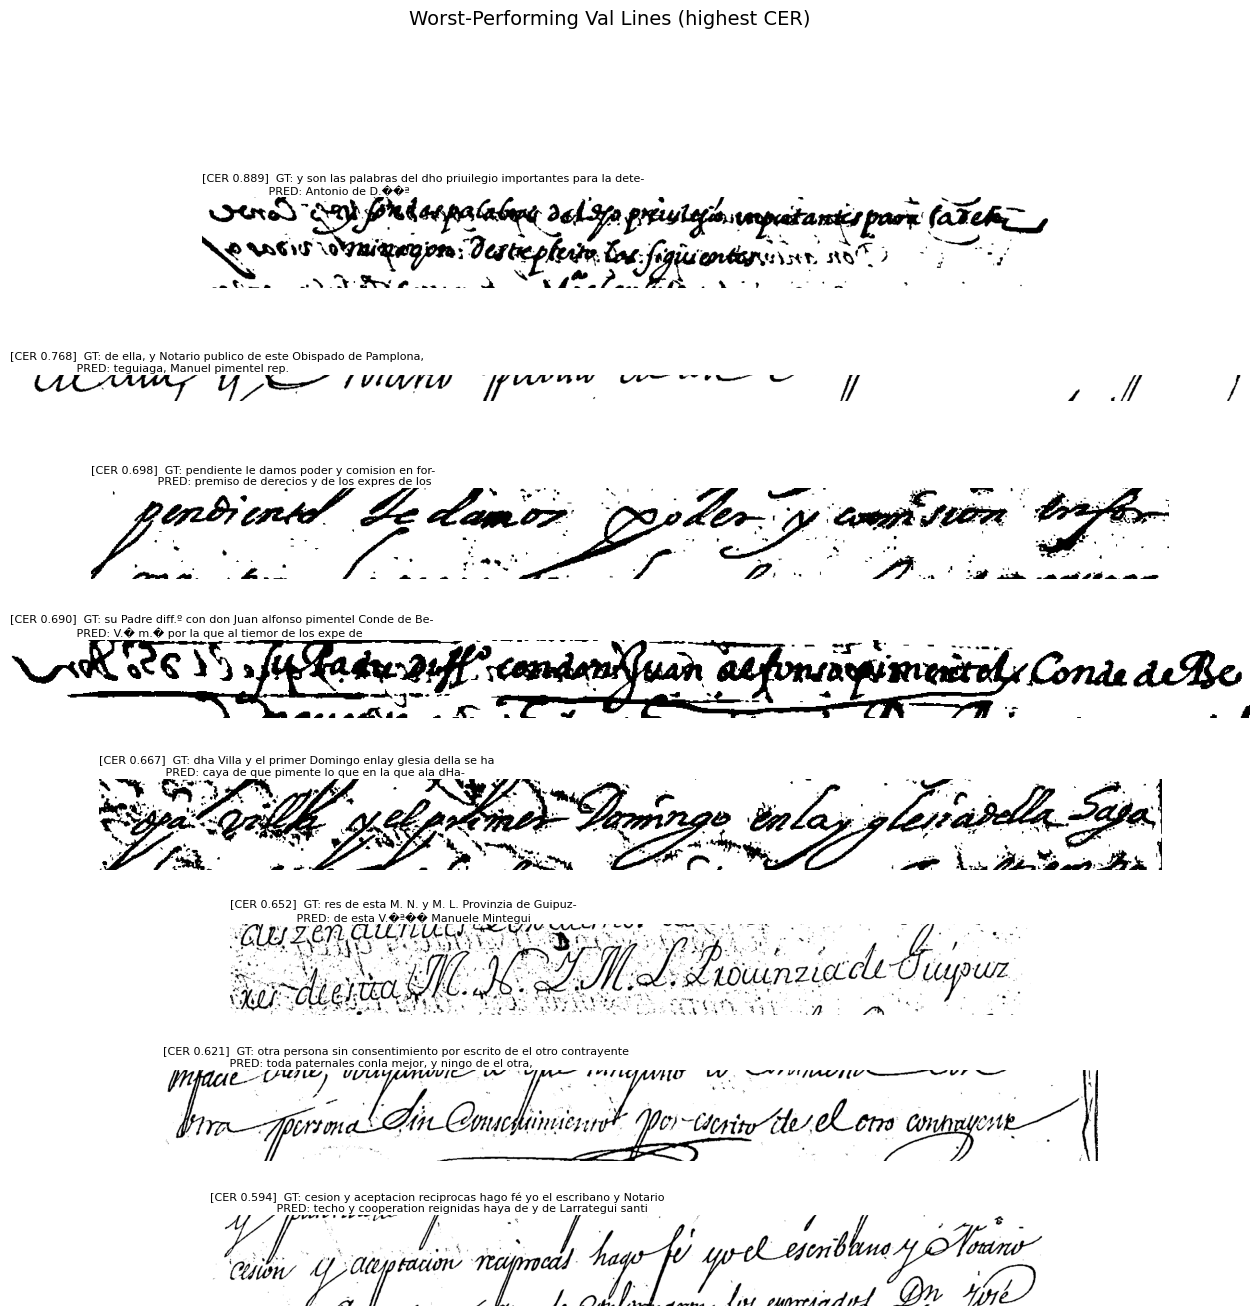


Error analysis plot saved to /content/renaissance_htr/error_analysis.png


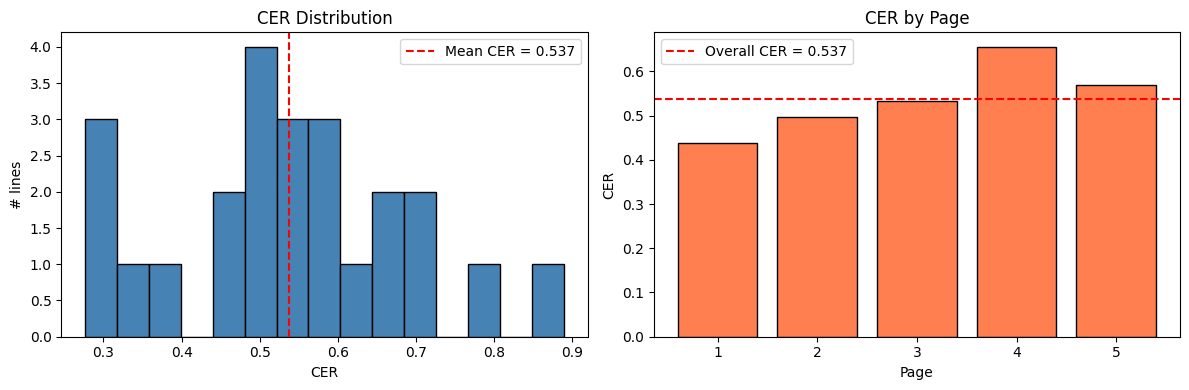


All outputs saved to /content/drive/MyDrive/Spanish_16c/model_output

  Baseline training complete.
  CER = 0.5371  |  WER = 0.7984


In [ ]:
# ── CELL 10 · Final evaluation + error analysis ───────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

def run_error_analysis(
    model, processor, val_samples, image_dir, n_display=8
):
    """
    Runs inference on the full val set, prints CER/WER per sample,
    and displays a grid of worst-performing lines.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    cer_fn = evaluate.load("cer")
    wer_fn = evaluate.load("wer")

    results = []

    for sample in val_samples:
        img_path = os.path.join(image_dir, sample["image"])
        img      = Image.open(img_path).convert("RGB")

        pixel_values = processor(img, return_tensors="pt").pixel_values.to(device)

        with torch.no_grad():
            generated_ids = model.generate(
                pixel_values,
                num_beams       = 4,
                max_new_tokens  = 128,
                early_stopping  = True,
                no_repeat_ngram_size = 3,
            )

        pred  = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
        truth = sample["text"].strip()

        sample_cer = cer_fn.compute(predictions=[pred], references=[truth])
        sample_wer = wer_fn.compute(predictions=[pred], references=[truth])

        results.append({
            "image":  sample["image"],
            "truth":  truth,
            "pred":   pred,
            "cer":    sample_cer,
            "wer":    sample_wer,
            "page":   sample["page"],
        })

    # ── Aggregate metrics ─────────────────────────────────────────────────
    all_preds  = [r["pred"]  for r in results]
    all_truths = [r["truth"] for r in results]
    overall_cer = cer_fn.compute(predictions=all_preds, references=all_truths)
    overall_wer = wer_fn.compute(predictions=all_preds, references=all_truths)

    print("\n" + "=" * 60)
    print(f"  FINAL EVALUATION  ({len(results)} val lines)")
    print("=" * 60)
    print(f"  CER : {overall_cer:.4f}  ({(1-overall_cer)*100:.1f}% char accuracy)")
    print(f"  WER : {overall_wer:.4f}  ({(1-overall_wer)*100:.1f}% word accuracy)")
    print("=" * 60)

    # ── Per-page CER breakdown ────────────────────────────────────────────
    print("\nPer-page CER:")
    pages = sorted(set(r["page"] for r in results))
    page_cers = {}
    for page in pages:
        page_results = [r for r in results if r["page"] == page]
        page_preds   = [r["pred"]  for r in page_results]
        page_truths  = [r["truth"] for r in page_results]
        if page_preds:
            pc = cer_fn.compute(predictions=page_preds, references=page_truths)
            page_cers[page] = pc
            print(f"  Page {page:2d} — CER {pc:.4f}  ({len(page_results)} lines)")

    # ── Worst 8 lines ─────────────────────────────────────────────────────
    worst = sorted(results, key=lambda r: r["cer"], reverse=True)[:n_display]

    fig = plt.figure(figsize=(16, n_display * 1.8))
    fig.suptitle("Worst-Performing Val Lines (highest CER)", fontsize=14, y=1.01)
    gs  = gridspec.GridSpec(n_display, 1, figure=fig, hspace=0.6)

    for i, r in enumerate(worst):
        ax  = fig.add_subplot(gs[i])
        img = Image.open(os.path.join(image_dir, r["image"])).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(
            f"[CER {r['cer']:.3f}]  GT: {r['truth']}\n"
            f"                   PRED: {r['pred']}",
            fontsize=8, loc="left", pad=2,
        )

    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, "error_analysis.png"),
                dpi=120, bbox_inches="tight")
    plt.show()
    print(f"\nError analysis plot saved to {WORK_DIR}/error_analysis.png")

    # ── CER distribution plot ─────────────────────────────────────────────
    fig2, axes = plt.subplots(1, 2, figsize=(12, 4))

    cers = [r["cer"] for r in results]
    axes[0].hist(cers, bins=15, edgecolor="black", color="steelblue")
    axes[0].axvline(overall_cer, color="red", linestyle="--",
                    label=f"Mean CER = {overall_cer:.3f}")
    axes[0].set_xlabel("CER")
    axes[0].set_ylabel("# lines")
    axes[0].set_title("CER Distribution")
    axes[0].legend()

    axes[1].bar(list(page_cers.keys()), list(page_cers.values()),
                color="coral", edgecolor="black")
    axes[1].set_xlabel("Page")
    axes[1].set_ylabel("CER")
    axes[1].set_title("CER by Page")
    axes[1].axhline(overall_cer, color="red", linestyle="--",
                    label=f"Overall CER = {overall_cer:.3f}")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, "cer_distribution.png"),
                dpi=120, bbox_inches="tight")
    plt.show()

    return results, overall_cer, overall_wer


# ── Run the analysis ──────────────────────────────────────────────────────────
val_results, final_cer, final_wer = run_error_analysis(
    model, processor, VAL_SAMPLES, EXPORT_DIR
)

# ── Save results to Drive ─────────────────────────────────────────────────────
DRIVE_SAVE = "/content/drive/MyDrive/Spanish_16c/model_output"
os.makedirs(DRIVE_SAVE, exist_ok=True)

import shutil
shutil.copytree(FINAL_MODEL_DIR, os.path.join(DRIVE_SAVE, "final_model"), dirs_exist_ok=True)
shutil.copy(os.path.join(WORK_DIR, "error_analysis.png"),   DRIVE_SAVE)
shutil.copy(os.path.join(WORK_DIR, "cer_distribution.png"), DRIVE_SAVE)

with open(os.path.join(DRIVE_SAVE, "val_results.json"), "w", encoding="utf-8") as f:
    json.dump(val_results, f, ensure_ascii=False, indent=2)

print(f"\nAll outputs saved to {DRIVE_SAVE}")
print(f"\n{'='*60}")
print(f"  Baseline training complete.")
print(f"  CER = {final_cer:.4f}  |  WER = {final_wer:.4f}")
print(f"{'='*60}")